In [168]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

In [169]:
data_solar = pd.read_csv("pv_optimal.csv", index_col = 0, sep = ";", parse_dates=True)
data_wind = pd.read_csv("onshore_wind_1979-2017.csv", index_col=0, sep = ";", parse_dates=True)
data_el = pd.read_csv("electricity_demand.csv", index_col = 0, sep = ";", parse_dates=True)

country = 'DNK'


In [170]:
data = {

    "capital_cost": [1560000/25, 814000/25, 724000/25],      # $/MW/a
    "marginal_cost": [0.0, 0.0, 61.2]            # $/MWh
}

# Creazione del DataFrame
costs = pd.DataFrame(data, index=["onwind", "solar", "CCGT"])

costs.head()

,capital_cost,marginal_cost
onwind,62400.0,0.0
solar,32560.0,0.0
CCGT,28960.0,61.2


Defining Network

In [171]:
dnk_n = pypsa.Network()


In [172]:
hours_in_2015 = pd.date_range('2015-01-01 00:00z', '2015-12-31 23:00Z', freq='h')

#print(hours_in_2015)

dnk_n.set_snapshots(hours_in_2015.values)





In [173]:
data_wind.index = data_wind.index.tz_localize(None)
CF_wind = data_wind.loc[dnk_n.snapshots, country].values
data_solar.index = data_solar.index.tz_localize(None)
CF_solar = data_solar.loc[dnk_n.snapshots, country].values


Adding the first and for now only node/bus ---> Denmark

In [174]:
dnk_n.add("Bus", "Denmark")

Defining carriers (technolgy generators or batteries)

In [175]:
carriers = ["onwind", "solar", "CCGT"]
dnk_n.add(
    "Carrier",
    carriers,
    color=["blue","red","brown"],
    )

Demand:

In [176]:
dnk_n.add("Load", "dnk_demand", bus = "Denmark", p_set = data_el[country].values
      )
#Denmark demand associated to the Denmark Bus

<Axes: xlabel='snapshot', ylabel='MW'>

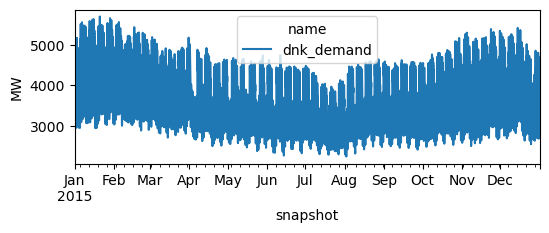

In [177]:
dnk_n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

Generators in Denmark:

In [178]:
# wind onshore
dnk_n.add(
    "Generator",
    "onwind", 
    bus = "Denmark", 
    carrier = "onwind", 
    capital_cost =  costs.loc["onwind", "capital_cost"],
    marginal_cost = costs.loc["onwind", "marginal_cost"],
    p_max_pu = CF_wind,
    p_nom_extendable = True
    )

In [179]:
# solar
dnk_n.add(
    "Generator",
    "solar", 
    bus = "Denmark", 
    carrier = "solar", 
    capital_cost = costs.loc["solar", "capital_cost"] ,
    marginal_cost = costs.loc["solar", "marginal_cost"],
    p_max_pu = CF_solar,
    p_nom_extendable = True
    )

In [180]:
# CCGT
dnk_n.add(
    "Generator",
    "CCGT", 
    bus = "Denmark", 
    carrier = "CCGT", 
    capital_cost = costs.loc["CCGT", "capital_cost"] ,
    marginal_cost = costs.loc["CCGT", "marginal_cost"],
    efficiency = 0.58 ,
    p_nom_extendable = True
    )

<Axes: xlabel='snapshot', ylabel='CF'>

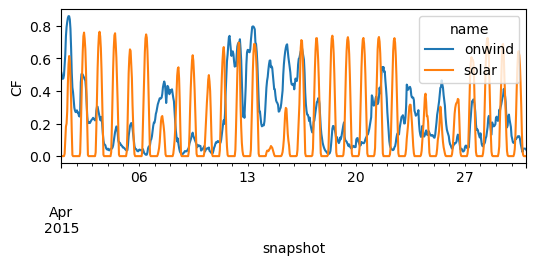

In [194]:
dnk_n.generators_t.p_max_pu.loc["2015-04"].plot(figsize=(6, 2), ylabel="CF")

Optimize!

In [181]:
dnk_n.optimize(solver_name = "gurobi")

C:\Users\terry\AppData\Local\Temp\ipykernel_31920\3996168487.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 119.40it/s]
INFO:linopy.io: Writing time: 0.13s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


...

Solved in 1490 iterations and 1.91 seconds (0.32 work units)


INFO:gurobipy:Solved in 1490 iterations and 1.91 seconds (0.32 work units)


Optimal objective  1.545342013e+09


INFO:gurobipy:Optimal objective  1.545342013e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.55e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

Results:

In [182]:
#objective value
print("objective value: ", dnk_n.objective)

objective value:  1545342012.88762


In [183]:
#capacities installed
print("in GW \n", dnk_n.generators.p_nom_opt)

in GW 
 name
onwind    8207.836066
solar     4367.109457
CCGT      5388.620295
Name: p_nom_opt, dtype: float64


In [184]:
#hour production for each technology
hourly_prod = dnk_n.generators_t.p
print(hourly_prod)
dnk_n.generators_t.p.to_csv("hourly_dnk_production.csv")

name                      onwind  solar         CCGT
snapshot                                            
2015-01-01 00:00:00  3210.980000    0.0     0.000000
2015-01-01 01:00:00  3100.020000    0.0     0.000000
2015-01-01 02:00:00  2980.390000    0.0     0.000000
2015-01-01 03:00:00  2933.490000    0.0     0.000000
2015-01-01 04:00:00  2941.540000    0.0     0.000000
...                          ...    ...          ...
2015-12-31 19:00:00  1428.163475    0.0  2259.706525
2015-12-31 20:00:00  1190.136230    0.0  2345.413770
2015-12-31 21:00:00  1157.304885    0.0  2231.955115
2015-12-31 22:00:00  1346.085115    0.0  1916.184885
2015-12-31 23:00:00  1674.398557    0.0  1484.451443

[8760 rows x 3 columns]


In [185]:
#annual production for each technology
print(" in TWH \n", dnk_n.generators_t.p.sum()/1e6)


 in TWH 
 name
onwind    17.935488
solar      2.869864
CCGT      12.008587
dtype: float64


In [186]:
#hour income for each technology
hourly_income = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy())
print(hourly_income)
dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).to_csv("hourly_dnk_income.csv")


name                        onwind  solar           CCGT
snapshot                                                
2015-01-01 00:00:00       0.000000    0.0       0.000000
2015-01-01 01:00:00       0.000000    0.0       0.000000
2015-01-01 02:00:00       0.000000    0.0       0.000000
2015-01-01 03:00:00       0.000000    0.0       0.000000
2015-01-01 04:00:00       0.000000    0.0       0.000000
...                            ...    ...            ...
2015-12-31 19:00:00   87403.604695    0.0  138294.039305
2015-12-31 20:00:00   72836.337246    0.0  143539.322754
2015-12-31 21:00:00   70827.058977    0.0  136595.653023
2015-12-31 22:00:00   82380.409023    0.0  117270.514977
2015-12-31 23:00:00  102473.191711    0.0   90848.428289

[8760 rows x 3 columns]


In [187]:
#annual income for each technology
incomes_y = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).sum()
print(incomes_y)

name
onwind    5.121690e+08
solar     1.421931e+08
CCGT      8.909800e+08
dtype: float64


In [188]:
#annual costs for each technology
costs_y = dnk_n.statistics.capex().add(dnk_n.statistics.opex(), fill_value=0)
print(costs_y)

component  carrier
Generator  CCGT       8.909800e+08
           onwind     5.121690e+08
           solar      1.421931e+08
dtype: float64


In [189]:
#hourly energy prices
energy_prices = dnk_n.buses_t.marginal_price
energy_prices.to_csv("annual_energy_prices_dnk.csv")

In [190]:
#annual scarsity revenue, it should be equal to capex cost for each technology
revenue = dnk_n.statistics.revenue(groupby=False)
opex = dnk_n.statistics.opex(groupby=False)


scarsity_revenue = revenue.sub(opex, fill_value=0)

print(scarsity_revenue.loc["Generator"])

print(dnk_n.statistics.capex())

name
CCGT      1.560544e+08
onwind    5.121690e+08
solar     1.421931e+08
dtype: float64
component  carrier
Generator  CCGT       1.560544e+08
           onwind     5.121690e+08
           solar      1.421931e+08
dtype: float64
